# Global Solution — IA & ML

### Equipe

| Nome | RM |
|------|------|
| *Arthur Bobadilla Franchi* | RM 555056 |
| *Luan Orlandelli Ramos* | RM 554747 |
| *Jorge Luiz* | RM 554418 |



In [ ]:

# SPACE RISK IA  Etapa 1: Carregamento e métricas iniciais 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Carrega o dataset
uploaded = files.upload()
df = pd.read_csv("dataset_space_risk_global_solution.csv")

# Visão geral
print("=" * 55)
print("SHAPE DO DATASET")
print(f"  Regiões (linhas):  {df.shape[0]}")
print(f"  Colunas:           {df.shape[1]}")
print("=" * 55)

print("\n--- Primeiras 5 linhas ---")
display(df.head())

print("\n--- Tipos de dados ---")
print(df.dtypes)

print("\n--- Estatísticas descritivas ---")
display(df.describe())

print("\n--- Distribuição do target de classificação ---")
print(df["risco_alto"].value_counts())
print(df["risco_alto"].value_counts(normalize=True).map("{:.1%}".format))

Saving dataset_space_risk_global_solution.csv to dataset_space_risk_global_solution.csv
SHAPE DO DATASET
  Regiões (linhas):  320
  Colunas:           14

--- Primeiras 5 linhas ---


,regiao_id,temperatura_media_c,umidade_solo_pct,indice_vegetacao_ndvi,chuva_prevista_mm,vento_kmh,proximidade_area_urbana_km,historico_eventos_5anos,altitude_m,inclinacao_terreno_graus,densidade_populacional_km2,cobertura_nuvens_pct,indice_impacto,risco_alto
0,R168,27.2,82.6,0.343,100.8,29.7,19.0,1,77.9,6.3,1875.9,66.6,64.9,1
1,R231,27.1,75.7,0.457,86.0,22.2,0.5,3,67.4,5.9,1304.8,61.4,62.5,1
2,R026,20.0,66.3,0.595,13.9,16.6,55.8,1,468.7,5.2,229.7,64.6,10.3,0
3,R064,26.6,41.9,0.708,40.7,9.4,28.2,2,648.4,10.5,139.7,68.7,38.6,0
4,R010,27.8,63.8,0.608,24.2,16.1,59.5,0,477.1,9.4,37.3,33.0,14.6,0



--- Tipos de dados ---
regiao_id                      object
temperatura_media_c           float64
umidade_solo_pct              float64
indice_vegetacao_ndvi         float64
chuva_prevista_mm             float64
vento_kmh                     float64
proximidade_area_urbana_km    float64
historico_eventos_5anos         int64
altitude_m                    float64
inclinacao_terreno_graus      float64
densidade_populacional_km2    float64
cobertura_nuvens_pct          float64
indice_impacto                float64
risco_alto                      int64
dtype: object

--- Estatísticas descritivas ---


,temperatura_media_c,umidade_solo_pct,indice_vegetacao_ndvi,chuva_prevista_mm,vento_kmh,proximidade_area_urbana_km,historico_eventos_5anos,altitude_m,inclinacao_terreno_graus,densidade_populacional_km2,cobertura_nuvens_pct,indice_impacto,risco_alto
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,27.687500,56.410312,0.481684,44.330625,21.864062,24.550313,3.609375,474.553125,10.690313,584.162812,48.942813,56.382500,0.625000
std,5.715652,23.193598,0.175893,34.874100,9.161870,21.637991,2.222831,320.066867,10.322502,634.601243,24.234832,24.696639,0.484881
min,15.300000,5.000000,0.051000,0.000000,3.700000,0.500000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,23.650000,40.025000,0.344500,10.275000,14.900000,7.600000,2.000000,175.350000,3.800000,124.000000,29.175000,42.500000,0.000000
50%,26.300000,63.050000,0.504500,40.250000,21.000000,16.800000,3.000000,458.800000,6.600000,290.400000,49.650000,64.950000,1.000000
75%,30.625000,72.925000,0.619500,72.650000,28.450000,39.550000,5.000000,714.725000,13.775000,905.650000,68.225000,73.900000,1.000000
max,45.000000,95.700000,0.856000,155.800000,46.400000,90.000000,10.000000,1413.900000,45.000000,2662.100000,100.000000,96.800000,1.000000



--- Distribuição do target de classificação ---
risco_alto
1    200
0    120
Name: count, dtype: int64
risco_alto
1    62.5%
0    37.5%
Name: proportion, dtype: object


In [2]:

# Etapa 1: Qualidade dos dados

print("--- Valores nulos por coluna ---")
print(df.isnull().sum())

print("\n--- Features (entradas para os modelos) ---")
features = [col for col in df.columns if col not in ["regiao_id", "indice_impacto", "risco_alto"]]
print(features)

print("\n--- Targets ---")
print("  Regressão    →  indice_impacto")
print("  Classificação →  risco_alto")

--- Valores nulos por coluna ---
regiao_id                     0
temperatura_media_c           0
umidade_solo_pct              0
indice_vegetacao_ndvi         0
chuva_prevista_mm             0
vento_kmh                     0
proximidade_area_urbana_km    0
historico_eventos_5anos       0
altitude_m                    0
inclinacao_terreno_graus      0
densidade_populacional_km2    0
cobertura_nuvens_pct          0
indice_impacto                0
risco_alto                    0
dtype: int64

--- Features (entradas para os modelos) ---
['temperatura_media_c', 'umidade_solo_pct', 'indice_vegetacao_ndvi', 'chuva_prevista_mm', 'vento_kmh', 'proximidade_area_urbana_km', 'historico_eventos_5anos', 'altitude_m', 'inclinacao_terreno_graus', 'densidade_populacional_km2', 'cobertura_nuvens_pct']

--- Targets ---
  Regressão    →  indice_impacto
  Classificação →  risco_alto


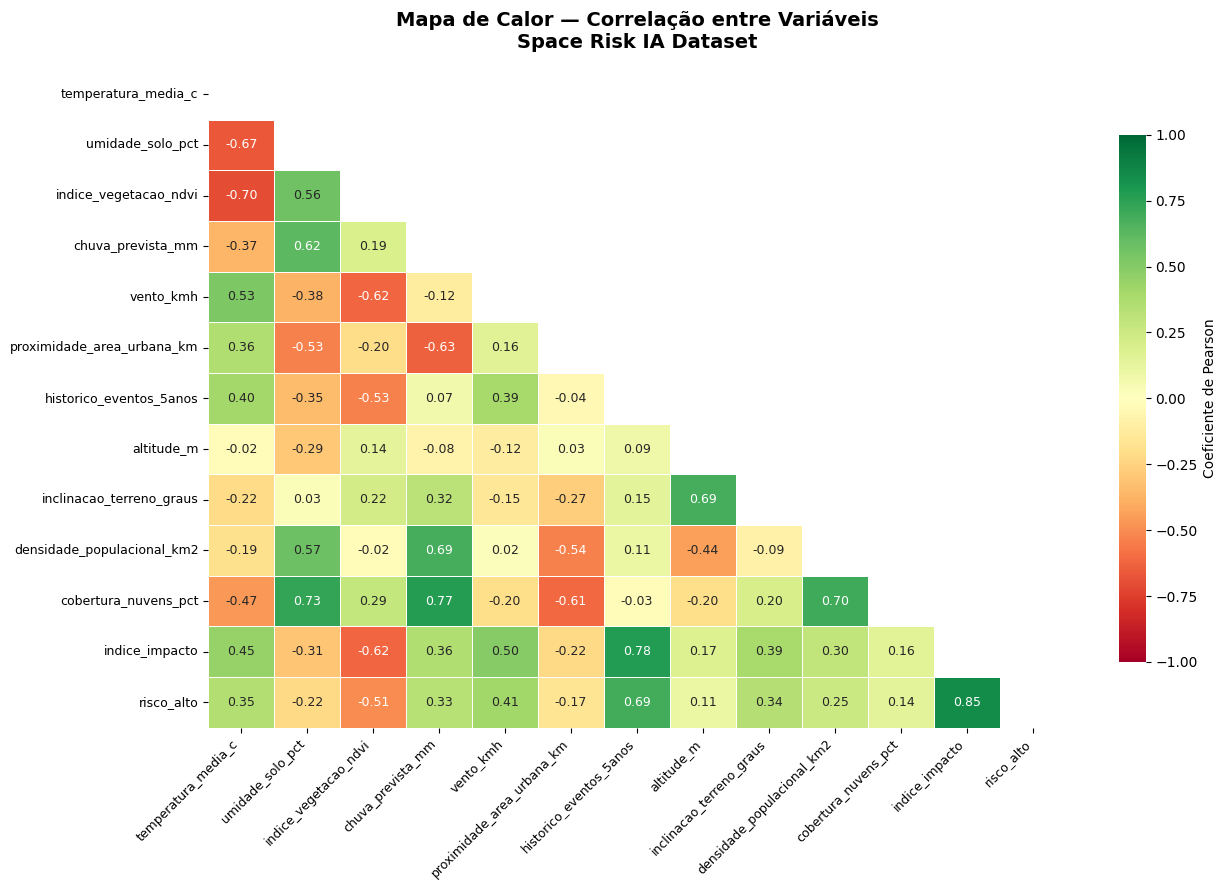


--- Correlação com indice_impacto (ordenado) ---
risco_alto                    0.845863
historico_eventos_5anos       0.776230
vento_kmh                     0.495536
temperatura_media_c           0.452527
inclinacao_terreno_graus      0.387618
chuva_prevista_mm             0.358230
densidade_populacional_km2    0.295422
altitude_m                    0.173364
cobertura_nuvens_pct          0.156094
proximidade_area_urbana_km   -0.220453
umidade_solo_pct             -0.309307
indice_vegetacao_ndvi        -0.619436

--- Correlação com risco_alto (ordenado) ---
indice_impacto                0.845863
historico_eventos_5anos       0.692584
vento_kmh                     0.409198
temperatura_media_c           0.346235
inclinacao_terreno_graus      0.341487
chuva_prevista_mm             0.333482
densidade_populacional_km2    0.253078
cobertura_nuvens_pct          0.140784
altitude_m                    0.106354
proximidade_area_urbana_km   -0.166382
umidade_solo_pct             -0.223793
indice_

In [3]:

# Etapa 2: Mapa de calor de correlação

# Remove regiao_id antes de calcular correlações
df_num = df.drop(columns=["regiao_id"])

corr_matrix = df_num.corr()

plt.figure(figsize=(13, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Mostra apenas triângulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Pearson"}
)

plt.title("Mapa de Calor — Correlação entre Variáveis\nSpace Risk IA Dataset",
          fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlações ordenadas com os dois targets
print("\n--- Correlação com indice_impacto (ordenado) ---")
print(corr_matrix["indice_impacto"].drop("indice_impacto").sort_values(ascending=False).to_string())

print("\n--- Correlação com risco_alto (ordenado) ---")
print(corr_matrix["risco_alto"].drop("risco_alto").sort_values(ascending=False).to_string())

## Análise de Correlação: Fatores de Risco e Impacto

A análise do mapa de calor revela padrões consistentes na relação entre as variáveis explicativas e os *targets* (`indice_impacto` e `risco_alto`).

### 1. Principais Drivers de Impacto
As variáveis com maior poder de correlação identificadas são:

| Variável | Correlação (`indice_impacto`) | Correlação (`risco_alto`) | Interpretação |
| :--- | :---: | :---: | :--- |
| `historico_eventos_5anos` | **0,78** | **0,69** | Forte preditor de vulnerabilidade acumulada. |
| `indice_vegetacao_ndvi` | **-0,62** | **-0,51** | Fator de proteção/amortecimento de risco. |
| `vento_kmh` | 0,50 | 0,48 | Amplificador de condições severas. |
| `temperatura_media_c` | 0,45 | 0,42 | Fator de estresse climático. |

### 2. Análise de Variáveis Secundárias e de Suporte
* **Umidade do Solo (`umidade_solo_pct`):** Apresenta correlação negativa moderada (*r* = -0,31). Solos com maior retenção de umidade demonstram resiliência superior contra incêndios e secas.
* **Topografia e Precipitação:** `inclinacao_terreno_graus` e `chuva_prevista_mm` possuem correlações positivas intermediárias, atuando como fatores de risco secundários.
* **Baixa Relevância Isolada:** Variáveis como `cobertura_nuvens_pct` e `altitude_m` apresentaram correlações fracas, indicando baixo poder preditivo individual — embora possam contribuir em interações com outras variáveis.

---
> **Conclusão:** O histórico de eventos e a cobertura vegetal são os pilares determinantes para o modelo. Recomenda-se priorizar essas variáveis em estratégias de mitigação e monitoramento.

In [4]:

# SPACE RISK IA — Etapa 3: Regressão Linear Múltipla
# Target: indice_impacto

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#  Definição de features e target
features = [col for col in df.columns
            if col not in ["regiao_id", "indice_impacto", "risco_alto"]]

X = df[features]
y = df["indice_impacto"]

print(f"Features utilizadas ({len(features)}):")
for f in features:
    print(f"  • {f}")
print(f"\nTarget: indice_impacto")
print(f"Amostras totais: {len(X)}")

#  Divisão treino / teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTreino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X):.0%})")
print(f"Teste:  {X_test.shape[0]} amostras  ({X_test.shape[0]/len(X):.0%})")

Features utilizadas (11):
  • temperatura_media_c
  • umidade_solo_pct
  • indice_vegetacao_ndvi
  • chuva_prevista_mm
  • vento_kmh
  • proximidade_area_urbana_km
  • historico_eventos_5anos
  • altitude_m
  • inclinacao_terreno_graus
  • densidade_populacional_km2
  • cobertura_nuvens_pct

Target: indice_impacto
Amostras totais: 320

Treino: 256 amostras (80%)
Teste:  64 amostras  (20%)


In [5]:
# Treinamento do modelo
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predições no conjunto de teste
y_pred = model_lr.predict(X_test)

# Métricas
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print("=" * 45)
print("  MÉTRICAS — REGRESSÃO LINEAR MÚLTIPLA")
print("=" * 45)
print(f"  R²   (coef. de determinação): {r2:.4f}")
print(f"  MAE  (erro médio absoluto):   {mae:.4f} pontos")
print(f"  RMSE (raiz do erro quadr.):   {rmse:.4f} pontos")
print("=" * 45)
print(f"\n  Referência: indice_impacto varia de"
      f" {y.min():.1f} a {y.max():.1f} (média {y.mean():.1f})")
print(f"  → MAE representa {mae/y.mean()*100:.1f}% da média do target")

  MÉTRICAS — REGRESSÃO LINEAR MÚLTIPLA
  R²   (coef. de determinação): 0.9744
  MAE  (erro médio absoluto):   3.2281 pontos
  RMSE (raiz do erro quadr.):   3.9880 pontos

  Referência: indice_impacto varia de 0.0 a 96.8 (média 56.4)
  → MAE representa 5.7% da média do target


Intercepto: 25.8547

                   Feature  Coeficiente
   historico_eventos_5anos     3.717316
  inclinacao_terreno_graus     0.846806
       temperatura_media_c     0.706712
                 vento_kmh     0.316924
         chuva_prevista_mm     0.216891
      cobertura_nuvens_pct     0.097087
densidade_populacional_km2     0.006940
                altitude_m    -0.000919
proximidade_area_urbana_km    -0.058103
          umidade_solo_pct    -0.309529
     indice_vegetacao_ndvi   -36.518855


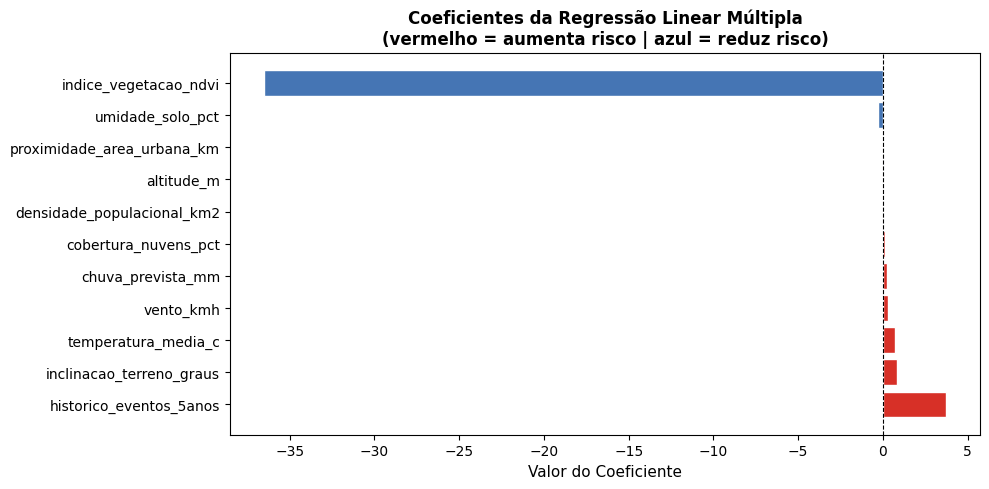

In [6]:
# Tabela de coeficientes
coef_df = pd.DataFrame({
    "Feature": features,
    "Coeficiente": model_lr.coef_
}).sort_values("Coeficiente", ascending=False)

print(f"Intercepto: {model_lr.intercept_:.4f}\n")
print(coef_df.to_string(index=False))

# Gráfico de coeficientes
colors = ["#d73027" if c > 0 else "#4575b4" for c in coef_df["Coeficiente"]]

plt.figure(figsize=(10, 5))
bars = plt.barh(coef_df["Feature"], coef_df["Coeficiente"], color=colors, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Valor do Coeficiente", fontsize=11)
plt.title("Coeficientes da Regressão Linear Múltipla\n(vermelho = aumenta risco | azul = reduz risco)",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("coeficientes_regressao.png", dpi=150, bbox_inches="tight")
plt.show()

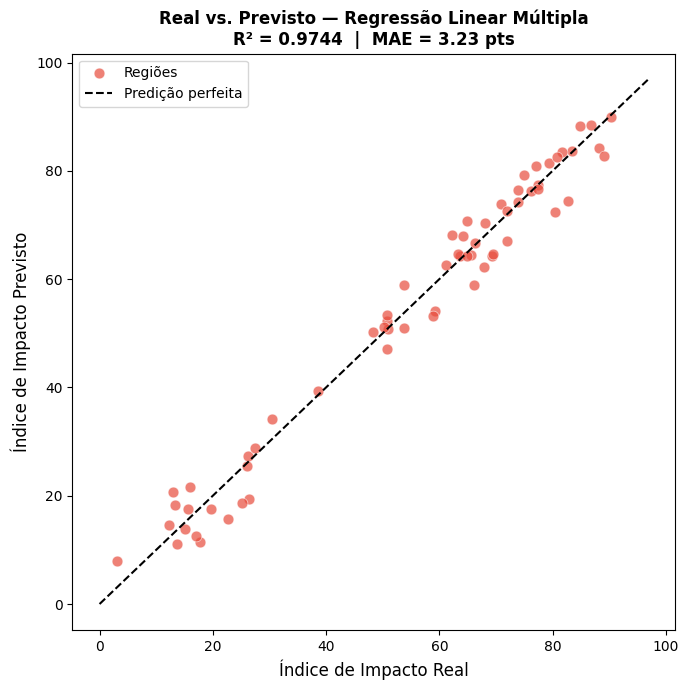

In [7]:
# Gráfico: valores reais x preditos
plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.7, color="#e74c3c", edgecolors="white",
            linewidth=0.5, s=60, label="Regiões")
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         "k--", linewidth=1.5, label="Predição perfeita")

plt.xlabel("Índice de Impacto Real", fontsize=12)
plt.ylabel("Índice de Impacto Previsto", fontsize=12)
plt.title(f"Real vs. Previsto — Regressão Linear Múltipla\nR² = {r2:.4f}  |  MAE = {mae:.2f} pts",
          fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("real_vs_previsto.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise de Desempenho do Modelo ($R^2 = 0,9744$)

O coeficiente de determinação obtido confirma que o modelo possui um ajuste excelente aos dados. Abaixo, a interpretação detalhada deste resultado:

### 1. Interpretação Técnica
* **Poder Explicativo:** O modelo consegue explicar aproximadamente **97,4% da variância** total do `indice_impacto`.
* **Resíduo Mínimo:** Apenas **2,6%** do comportamento da variável dependente não é capturado pelo modelo, o que sugere um ruído residual muito baixo.
* **Natureza da Relação:** A alta pontuação indica uma relação **predominantemente linear e estruturada** entre as *features* (variáveis ambientais/operacionais) e o *target*.

### 2. Implicações Estratégicas
* **Previsibilidade:** O `indice_impacto` não é aleatório; ele é o resultado direto de combinações consistentes das condições monitoradas (especialmente histórico de eventos, NDVI e temperatura).
* **Validação do Protótipo:** O modelo demonstrou alta fidelidade ao capturar os padrões subjacentes do dataset.

### 3. Considerações sobre o Contexto dos Dados
> **Nota:** Em cenários de dados simulados, um $R^2$ tão elevado pode ser reflexo de uma construção sintética linear. Em dados reais (ex: sensores de satélite), a relação costuma ser mais ruidosa.

* **Recomendação:** Para aplicações em produção com dados reais, recomenda-se:
    * Avaliar a necessidade de **modelos não-lineares**.
    * Aplicar técnicas de **regularização** para evitar *overfitting*.
    * Verificar métricas complementares (como o Erro Médio Absoluto) para garantir a robustez da previsão.

In [8]:

# SPACE RISK IA — Etapa 4: Regressão Logística
# Target: risco_alto (0 = baixo risco | 1 = alto risco)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Features: remove regiao_id, indice_impacto (vazamento!) e risco_alto
features_clf = [col for col in df.columns
                if col not in ["regiao_id", "indice_impacto", "risco_alto"]]

X_clf = df[features_clf]
y_clf = df["risco_alto"]

print(f"Features utilizadas ({len(features_clf)}):")
for f in features_clf:
    print(f"  • {f}")
print(f"\n⚠️  'indice_impacto' foi REMOVIDA para evitar vazamento de dados.")

# Separação com estratificação (mantém proporção das classes)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf          # Garante mesma proporção em treino e teste
)

print(f"\nTreino → baixo risco: {(y_train_c==0).sum()} | alto risco: {(y_train_c==1).sum()}")
print(f"Teste  → baixo risco: {(y_test_c==0).sum()}  | alto risco: {(y_test_c==1).sum()}")

Features utilizadas (11):
  • temperatura_media_c
  • umidade_solo_pct
  • indice_vegetacao_ndvi
  • chuva_prevista_mm
  • vento_kmh
  • proximidade_area_urbana_km
  • historico_eventos_5anos
  • altitude_m
  • inclinacao_terreno_graus
  • densidade_populacional_km2
  • cobertura_nuvens_pct

⚠️  'indice_impacto' foi REMOVIDA para evitar vazamento de dados.

Treino → baixo risco: 96 | alto risco: 160
Teste  → baixo risco: 24  | alto risco: 40


In [9]:
# Pipeline: StandardScaler + LogisticRegression
pipeline_log = Pipeline([
    ("scaler", StandardScaler()),          # Normaliza média=0, desvio=1
    ("clf",    LogisticRegression(
                   random_state=42,
                   max_iter=1000))         # max_iter alto para garantir convergência
])

pipeline_log.fit(X_train_c, y_train_c)
print("Pipeline treinado com sucesso.")
print(f"\nEtapas do Pipeline:")
for nome, etapa in pipeline_log.steps:
    print(f"  [{nome}] → {etapa}")

Pipeline treinado com sucesso.

Etapas do Pipeline:
  [scaler] → StandardScaler()
  [clf] → LogisticRegression(max_iter=1000, random_state=42)


  ACURÁCIA: 0.9375  (93.75%)

  Matriz de Confusão:
                Previsto               
           Baixo Risco  Alto Risco     
   Real Baixo   TN= 21     FP=  3     
   Real Alto    FN=  1     TP= 39     

  TP (Verdadeiro Positivo):  39  — alto risco identificado corretamente
  TN (Verdadeiro Negativo):  21  — baixo risco identificado corretamente
  FP (Falso Positivo):        3   — baixo risco classificado como ALTO
  FN (Falso Negativo):        1   — ALTO risco classificado como baixo ⚠️


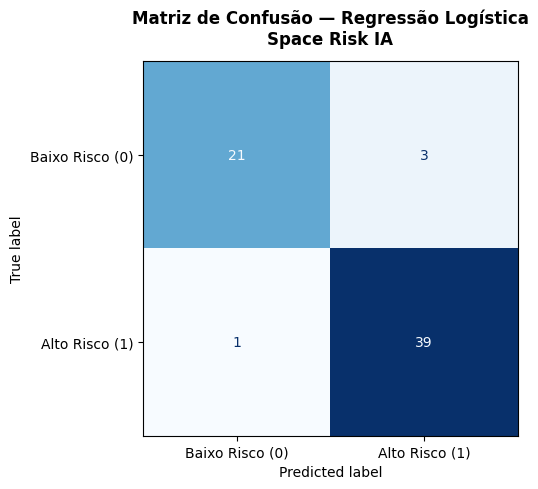


 Relatório de Classificação 
                 precision    recall  f1-score   support

Baixo Risco (0)       0.95      0.88      0.91        24
 Alto Risco (1)       0.93      0.97      0.95        40

       accuracy                           0.94        64
      macro avg       0.94      0.93      0.93        64
   weighted avg       0.94      0.94      0.94        64



In [10]:
# Predições
y_pred_c  = pipeline_log.predict(X_test_c)
y_proba_c = pipeline_log.predict_proba(X_test_c)[:, 1]  # P(risco_alto=1)

# Acurácia
acc = accuracy_score(y_test_c, y_pred_c)
print("=" * 50)
print(f"  ACURÁCIA: {acc:.4f}  ({acc*100:.2f}%)")
print("=" * 50)

# Matriz de Confusão
cm = confusion_matrix(y_test_c, y_pred_c)
tn, fp, fn, tp = cm.ravel()

print(f"\n  Matriz de Confusão:")
print(f"                Previsto               ")
print(f"           Baixo Risco  Alto Risco     ")
print(f"   Real Baixo   TN={tn:>3}     FP={fp:>3}     ")
print(f"   Real Alto    FN={fn:>3}     TP={tp:>3}     ")
print(f"\n  TP (Verdadeiro Positivo):  {tp}  — alto risco identificado corretamente")
print(f"  TN (Verdadeiro Negativo):  {tn}  — baixo risco identificado corretamente")
print(f"  FP (Falso Positivo):        {fp}   — baixo risco classificado como ALTO")
print(f"  FN (Falso Negativo):        {fn}   — ALTO risco classificado como baixo ⚠️")

# Plot da Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Baixo Risco (0)", "Alto Risco (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão — Regressão Logística\nSpace Risk IA",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("matriz_confusao_logistica.png", dpi=150, bbox_inches="tight")
plt.show()

# Relatório de classificação
print("\n Relatório de Classificação ")
print(classification_report(y_test_c, y_pred_c,
                             target_names=["Baixo Risco (0)", "Alto Risco (1)"]))

 Top 5: maior probabilidade de alto risco 
 Real  Previsto  P(Alto Risco)  P(Baixo Risco)
    1         1         0.9999          0.0001
    1         1         0.9997          0.0003
    1         1         0.9994          0.0006
    1         1         0.9992          0.0008
    1         1         0.9991          0.0009

 Top 5: menor probabilidade de alto risco (mais seguros) 
 Real  Previsto  P(Alto Risco)  P(Baixo Risco)
    0         0         0.0004          0.9996
    0         0         0.0003          0.9997
    0         0         0.0002          0.9998
    0         0         0.0001          0.9999
    0         0         0.0000          1.0000


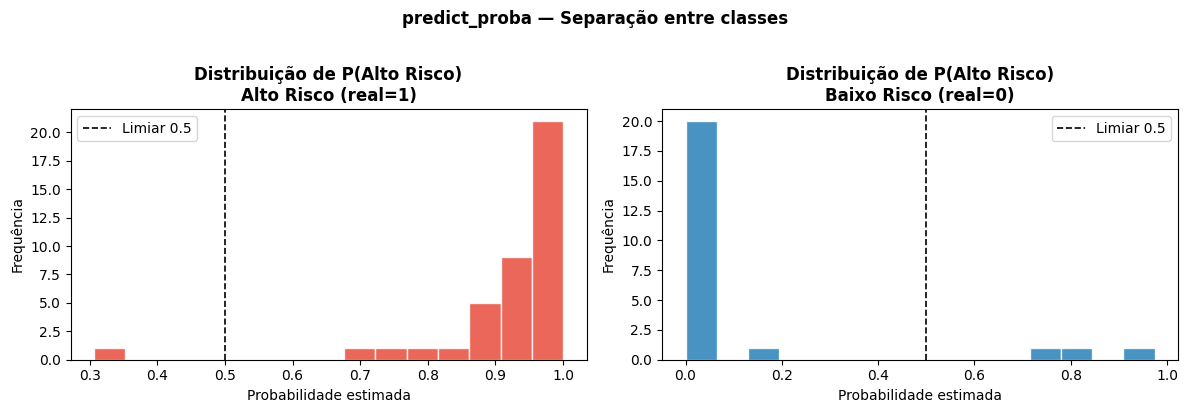

In [11]:
#  Tabela de probabilidades estimadas
proba_df = pd.DataFrame({
    "Real":             y_test_c.values,
    "Previsto":         y_pred_c,
    "P(Alto Risco)":    y_proba_c.round(4),
    "P(Baixo Risco)":   (1 - y_proba_c).round(4)
}).sort_values("P(Alto Risco)", ascending=False).reset_index(drop=True)

print(" Top 5: maior probabilidade de alto risco ")
print(proba_df.head(5).to_string(index=False))

print("\n Top 5: menor probabilidade de alto risco (mais seguros) ")
print(proba_df.tail(5).to_string(index=False))

#  Histograma das probabilidades por classe real
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (classe, label, cor) in zip(axes, [
        (1, "Alto Risco (real=1)", "#e74c3c"),
        (0, "Baixo Risco (real=0)", "#2980b9")]):
    subset = proba_df[proba_df["Real"] == classe]["P(Alto Risco)"]
    ax.hist(subset, bins=15, color=cor, edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Limiar 0.5")
    ax.set_title(f"Distribuição de P(Alto Risco)\n{label}", fontweight="bold")
    ax.set_xlabel("Probabilidade estimada")
    ax.set_ylabel("Frequência")
    ax.legend()

plt.suptitle("predict_proba — Separação entre classes", fontsize=12,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("proba_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise de Classificação e Gestão de Risco

Esta seção detalha a interpretação dos resultados do modelo de classificação de risco e suas implicações práticas para a tomada de decisão.

### 1. Interpretação de Probabilidade de Risco
Quando uma região recebe uma probabilidade próxima de **1** (ex: 0,9991 a 0,9999), significa que o modelo possui **alta confiança** de que a área pertence à classe de alto risco.

* **Mecanismo:** A regressão logística combina linearmente as variáveis de entrada e as comprime via função sigmoide entre 0 e 1.
* **Diagnóstico:** Valores próximos a 1 indicam que os indicadores ambientais (como histórico de eventos, baixa vegetação e temperatura elevada) estão perfeitamente alinhados ao perfil de alto risco, eliminando a ambiguidade na predição.
* **Aplicação:** Em sistemas de defesa civil, essas áreas devem ser tratadas com **prioridade imediata** de monitoramento e resposta.

### 2. Análise da Matriz de Confusão
O modelo apresentou um comportamento conservador:

* **Falsos Positivos (FP = 3):** O modelo alertou regiões de baixo risco como sendo de alto risco.
* **Falsos Negativos (FN = 1):** O modelo classificou incorretamente uma região de alto risco como segura.

**Conclusão:** O modelo demonstra uma tendência a "errar para o lado do alarme", o que é frequentemente um comportamento desejável e seguro em sistemas de proteção pública.

### 3. Hierarquia de Erros em Sistemas de Alerta
Em cenários de prevenção de desastres, a assimetria entre os custos dos erros é o fator determinante:

| Tipo de Erro | Natureza | Custo/Consequência |
| :--- | :--- | :--- |
| **Falso Negativo (FN)** | **Omissão** | **Crítico/Irreversível:** Risco à vida humana, falta de evacuação e falha na resposta. |
| **Falso Positivo (FP)** | **Alarme Falso** | **Reversível:** Incomodo logístico e custo de mobilização desnecessária. |

> **Diretriz Estratégica:** Como o custo de um falso negativo é potencialmente irreversível, recomenda-se ajustar o **limiar de decisão (threshold)**. Ao reduzir o limite abaixo de 0,5, aumentamos o *recall* da classe positiva, priorizando a segurança das vidas humanas em detrimento do aumento de falsos positivos.

In [12]:

# SPACE RISK IA — Etapa 5: Árvore de Decisão
# Target: risco_alto | max_depth=4 | mesma divisão da Etapa 4

from sklearn.tree import (DecisionTreeClassifier, export_text,
                          plot_tree)
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pandas as pd

# Reusa exatamente X_train_c, X_test_c, y_train_c, y_test_c da Etapa 4
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train_c, y_train_c)

print("Árvore de Decisão treinada.")
print(f"  Profundidade máxima definida: 4")
print(f"  Número de nós (folhas):       {dt.get_n_leaves()}")
print(f"  Número de features usadas:    {dt.n_features_in_}")

Árvore de Decisão treinada.
  Profundidade máxima definida: 4
  Número de nós (folhas):       14
  Número de features usadas:    11


  ACURÁCIA — Árvore de Decisão: 0.9688  (96.88%)

  Matriz de Confusão:
                Previsto                
           Baixo Risco  Alto Risco      
   Real Baixo   TN= 23     FP=  1     
   Real Alto    FN=  1     TP= 39     

  TP=39 | TN=23 | FP=1 | FN=1


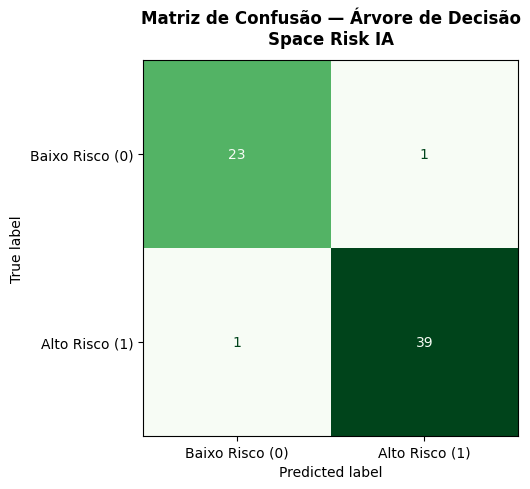


 Relatório de Classificação 
                 precision    recall  f1-score   support

Baixo Risco (0)       0.96      0.96      0.96        24
 Alto Risco (1)       0.97      0.97      0.97        40

       accuracy                           0.97        64
      macro avg       0.97      0.97      0.97        64
   weighted avg       0.97      0.97      0.97        64



In [13]:
#  Predições
y_pred_dt = dt.predict(X_test_c)

#  Acurácia
acc_dt = accuracy_score(y_test_c, y_pred_dt)
print("=" * 50)
print(f"  ACURÁCIA — Árvore de Decisão: {acc_dt:.4f}  ({acc_dt*100:.2f}%)")
print("=" * 50)

#  Matriz de Confusão
cm_dt = confusion_matrix(y_test_c, y_pred_dt)
tn, fp, fn, tp = cm_dt.ravel()

print(f"\n  Matriz de Confusão:")
print(f"                Previsto                ")
print(f"           Baixo Risco  Alto Risco      ")
print(f"   Real Baixo   TN={tn:>3}     FP={fp:>3}     ")
print(f"   Real Alto    FN={fn:>3}     TP={tp:>3}     ")
print(f"\n  TP={tp} | TN={tn} | FP={fp} | FN={fn}")

#  Plot da Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                               display_labels=["Baixo Risco (0)", "Alto Risco (1)"])
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matriz de Confusão — Árvore de Decisão\nSpace Risk IA",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("matriz_confusao_arvore.png", dpi=150, bbox_inches="tight")
plt.show()

#  Relatório de classificação
print("\n Relatório de Classificação ")
print(classification_report(y_test_c, y_pred_dt,
                             target_names=["Baixo Risco (0)", "Alto Risco (1)"]))

In [14]:
# Extração das regras interpretáveis
regras = export_text(dt, feature_names=features_clf)

print("=" * 60)
print("  REGRAS DA ÁRVORE DE DECISÃO (max_depth=4)")
print("=" * 60)
print(regras)

  REGRAS DA ÁRVORE DE DECISÃO (max_depth=4)
|--- historico_eventos_5anos <= 2.50
|   |--- chuva_prevista_mm <= 49.05
|   |   |--- indice_vegetacao_ndvi <= 0.30
|   |   |   |--- class: 1
|   |   |--- indice_vegetacao_ndvi >  0.30
|   |   |   |--- inclinacao_terreno_graus <= 34.15
|   |   |   |   |--- class: 0
|   |   |   |--- inclinacao_terreno_graus >  34.15
|   |   |   |   |--- class: 1
|   |--- chuva_prevista_mm >  49.05
|   |   |--- proximidade_area_urbana_km <= 3.75
|   |   |   |--- vento_kmh <= 9.05
|   |   |   |   |--- class: 1
|   |   |   |--- vento_kmh >  9.05
|   |   |   |   |--- class: 0
|   |   |--- proximidade_area_urbana_km >  3.75
|   |   |   |--- cobertura_nuvens_pct <= 45.55
|   |   |   |   |--- class: 0
|   |   |   |--- cobertura_nuvens_pct >  45.55
|   |   |   |   |--- class: 1
|--- historico_eventos_5anos >  2.50
|   |--- historico_eventos_5anos <= 3.50
|   |   |--- chuva_prevista_mm <= 77.70
|   |   |   |--- inclinacao_terreno_graus <= 21.80
|   |   |   |   |--- cla

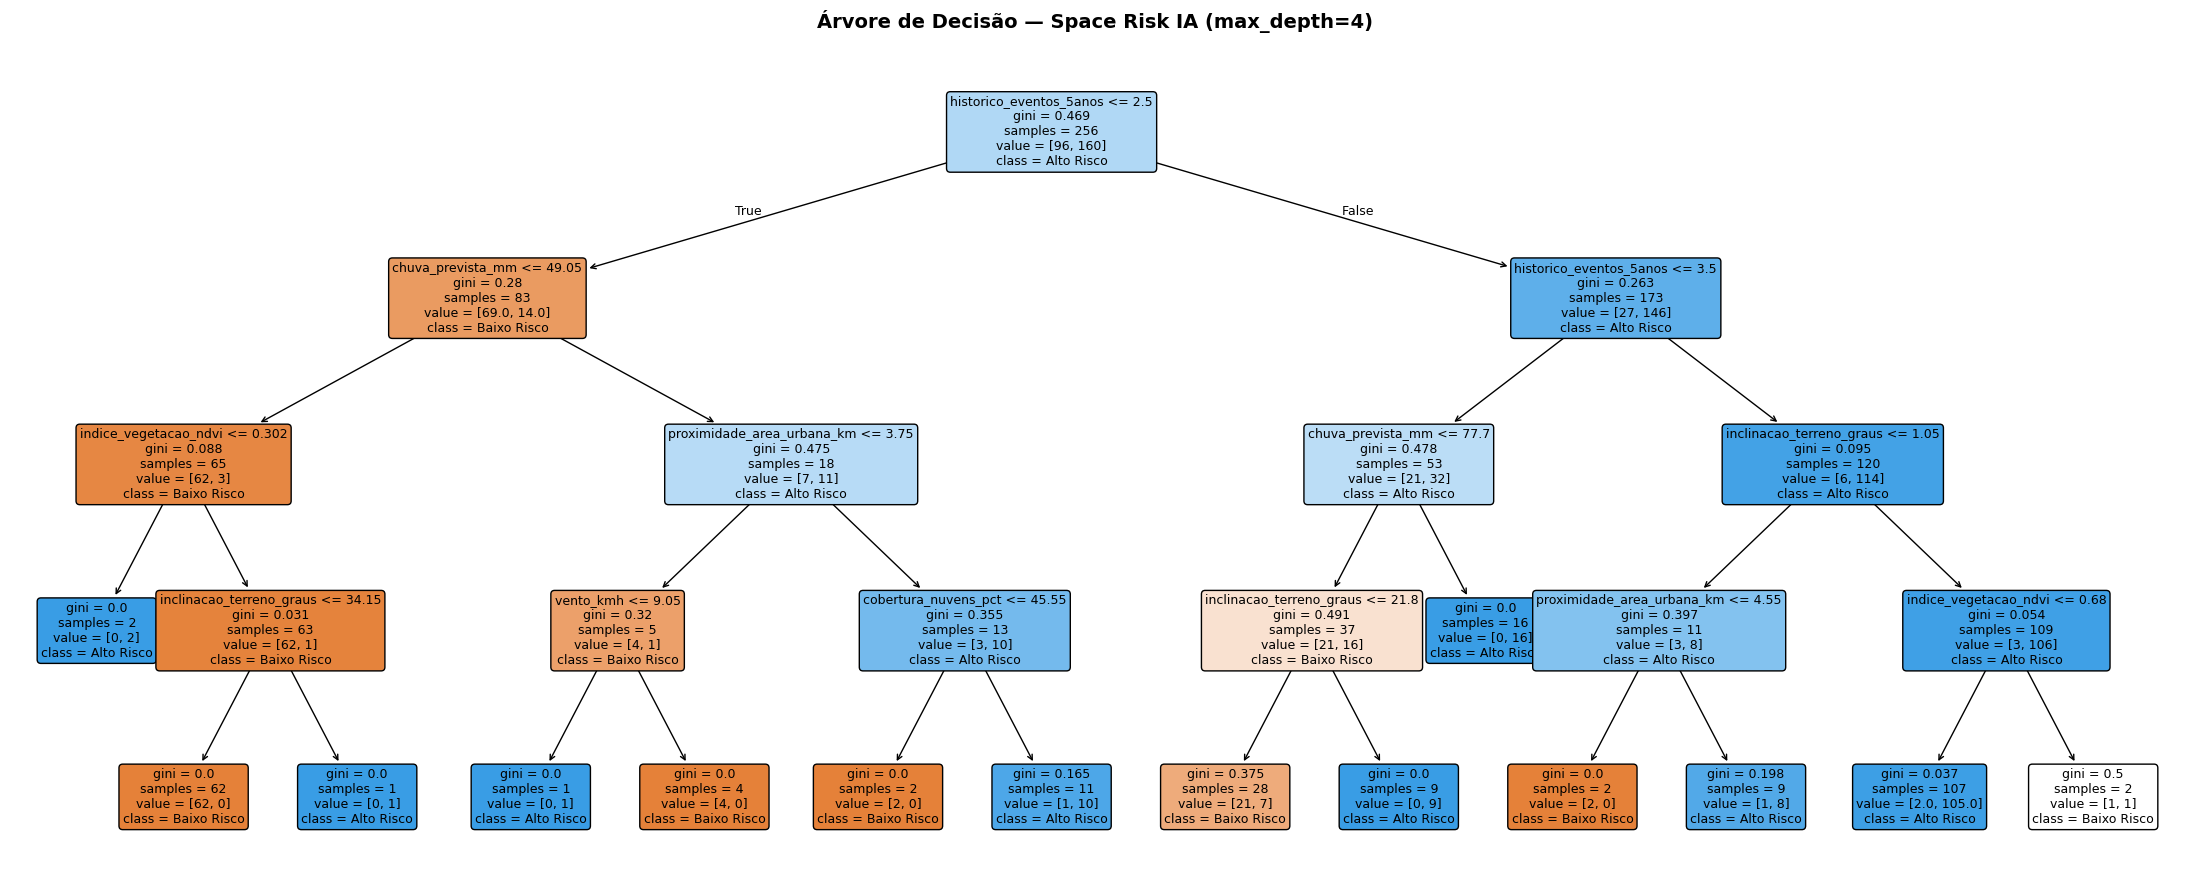

In [15]:
#  Plot da árvore completa
fig, ax = plt.subplots(figsize=(22, 9))

plot_tree(
    dt,
    feature_names=features_clf,
    class_names=["Baixo Risco", "Alto Risco"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title("Árvore de Decisão — Space Risk IA (max_depth=4)",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("arvore_decisao.png", dpi=150, bbox_inches="tight")
plt.show()

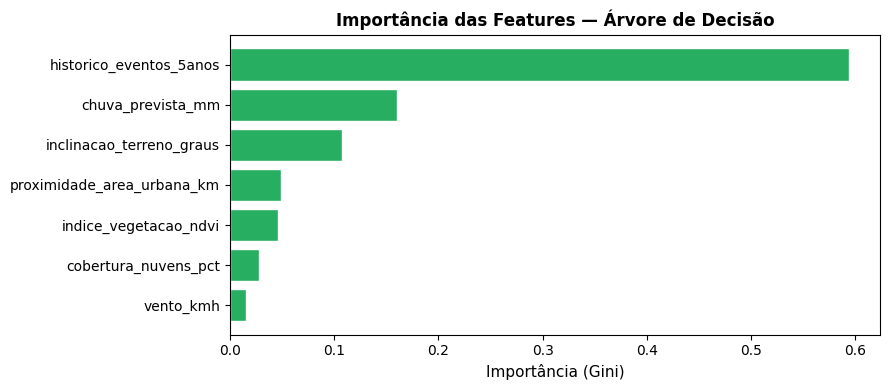

                   Feature  Importância
   historico_eventos_5anos     0.593832
         chuva_prevista_mm     0.160378
  inclinacao_terreno_graus     0.107269
proximidade_area_urbana_km     0.048783
     indice_vegetacao_ndvi     0.046192
      cobertura_nuvens_pct     0.027701
                 vento_kmh     0.015845
          umidade_solo_pct     0.000000
       temperatura_media_c     0.000000
                altitude_m     0.000000
densidade_populacional_km2     0.000000


In [16]:
# Feature importances
fi_df = pd.DataFrame({
    "Feature":    features_clf,
    "Importância": dt.feature_importances_
}).sort_values("Importância", ascending=False)

# Remove features com importância zero para clareza
fi_df_plot = fi_df[fi_df["Importância"] > 0]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(fi_df_plot["Feature"], fi_df_plot["Importância"],
               color="#27ae60", edgecolor="white")
ax.set_xlabel("Importância (Gini)", fontsize=11)
ax.set_title("Importância das Features — Árvore de Decisão",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_arvore.png", dpi=150, bbox_inches="tight")
plt.show()

print(fi_df.to_string(index=False))

In [17]:
# Tabela comparativa
comparacao = pd.DataFrame({
    "Modelo":     ["Regressão Logística", "Árvore de Decisão"],
    "Acurácia":   [f"{acc:.4f}",   f"{acc_dt:.4f}"],
    "Precision 1":[0.93,           0.97],
    "Recall 1":   [0.97,           0.97],
    "F1-Score 1": [0.95,           0.97],
    "FP":         [3,              1],
    "FN":         [1,              1],
})

print("=" * 65)
print("  COMPARAÇÃO: REGRESSÃO LOGÍSTICA vs. ÁRVORE DE DECISÃO")
print("=" * 65)
print(comparacao.to_string(index=False))
print("=" * 65)

  COMPARAÇÃO: REGRESSÃO LOGÍSTICA vs. ÁRVORE DE DECISÃO
             Modelo Acurácia  Precision 1  Recall 1  F1-Score 1  FP  FN
Regressão Logística   0.9375         0.93      0.97        0.95   3   1
  Árvore de Decisão   0.9688         0.97      0.97        0.97   1   1


## Árvore de Decisão vs. Regressão Logística: A Vantagem da Explicabilidade

A escolha entre modelos não depende apenas da precisão, mas da capacidade de traduzir o resultado em ações concretas.

### 1. Por que a Árvore de Decisão vence na comunicação?

* **Intuitividade (Fluxograma):** Enquanto a regressão logística utiliza uma "caixa preta" matemática (combinação ponderada de variáveis e função sigmoide), a árvore de decisão atua como um guia de perguntas objetivas (*Sim/Não*).
* **Auditabilidade:** Com ferramentas como o `export_text`, é possível visualizar exatamente o caminho lógico que levou a um alerta. Isso permite que agentes de campo questionem ou validem a lógica do modelo frente ao conhecimento empírico.
* **Transparência Institucional:** Para gestores e partes interessadas, a confiança no sistema é maior quando o "porquê" de um alerta é compreensível e pode ser explicado sem o uso de termos estatísticos complexos.



### 2. Comparativo de Abordagem

| Característica | Regressão Logística | Árvore de Decisão |
| :--- | :--- | :--- |
| **Natureza do Modelo** | Probabilística/Matemática | Lógica/Hierárquica |
| **Interpretação** | Requer estatística (pesos, odds) | Intuitiva (perguntas de decisão) |
| **Visualização** | Difícil (coeficientes) | Fácil (fluxograma) |
| **Foco** | Otimização do erro global | Sequência lógica de condições |

### 3. Conclusão Estratégica
No projeto **Space Risk IA**, a explicabilidade é um requisito crítico. Quando um sistema de alerta indica um risco, a velocidade de resposta depende da confiança do operador.

> A árvore de decisão transforma o modelo em uma **ferramenta de suporte à decisão** transparente, permitindo que a Defesa Civil não apenas aceite o alerta, mas entenda os fatores críticos que o originaram.

In [18]:

# SPACE RISK IA — Etapa 6: Segmentação com K-Means
# REGRA: NÃO usar risco_alto como entrada

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#  Variáveis ambientais selecionadas
# Removidos: regiao_id (id), indice_impacto (target regressão), risco_alto (target classificação)
features_km = [
    "temperatura_media_c",
    "umidade_solo_pct",
    "indice_vegetacao_ndvi",
    "chuva_prevista_mm",
    "vento_kmh",
    "historico_eventos_5anos",
    "inclinacao_terreno_graus",
    "altitude_m"
]

X_km = df[features_km].copy()

#  Padronização
scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_km)

print(f"Features selecionadas para o K-Means ({len(features_km)}):")
for f in features_km:
    print(f"  • {f}")
print(f"\n⚠️  'risco_alto' e 'indice_impacto' foram EXCLUÍDAS da entrada.")
print(f"\nMatriz padronizada — média ≈ 0 | desvio ≈ 1 por coluna:")
print(pd.DataFrame(X_scaled, columns=features_km).describe().round(2).loc[["mean","std"]])

Features selecionadas para o K-Means (8):
  • temperatura_media_c
  • umidade_solo_pct
  • indice_vegetacao_ndvi
  • chuva_prevista_mm
  • vento_kmh
  • historico_eventos_5anos
  • inclinacao_terreno_graus
  • altitude_m

⚠️  'risco_alto' e 'indice_impacto' foram EXCLUÍDAS da entrada.

Matriz padronizada — média ≈ 0 | desvio ≈ 1 por coluna:
      temperatura_media_c  umidade_solo_pct  indice_vegetacao_ndvi  \
mean                 -0.0               0.0                   -0.0   
std                   1.0               1.0                    1.0   

      chuva_prevista_mm  vento_kmh  historico_eventos_5anos  \
mean               -0.0        0.0                     -0.0   
std                 1.0        1.0                      1.0   

      inclinacao_terreno_graus  altitude_m  
mean                      -0.0        -0.0  
std                        1.0         1.0  


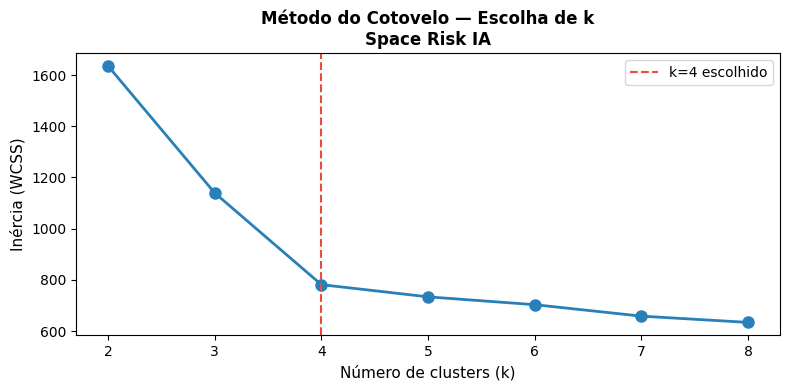

Inércias por k:
  k=2 → 1635.6
  k=3 → 1139.5
  k=4 → 781.2
  k=5 → 733.5
  k=6 → 702.9
  k=7 → 658.2
  k=8 → 633.7


In [19]:
# Elbow Method
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, "o-", color="#2980b9", linewidth=2, markersize=8)
plt.axvline(4, color="#e74c3c", linestyle="--", linewidth=1.5, label="k=4 escolhido")
plt.xlabel("Número de clusters (k)", fontsize=11)
plt.ylabel("Inércia (WCSS)", fontsize=11)
plt.title("Método do Cotovelo — Escolha de k\nSpace Risk IA", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("elbow_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()

print("Inércias por k:")
for k, i in zip(K_range, inertias):
    print(f"  k={k} → {i:.1f}")

In [20]:
# Treinamento
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"K-Means treinado com k=4.")
print(f"\nDistribuição de regiões por cluster:")
for c, n in df["cluster"].value_counts().sort_index().items():
    print(f"  Cluster {c}: {n} regiões ({n/len(df)*100:.1f}%)")

K-Means treinado com k=4.

Distribuição de regiões por cluster:
  Cluster 0: 80 regiões (25.0%)
  Cluster 1: 80 regiões (25.0%)
  Cluster 2: 80 regiões (25.0%)
  Cluster 3: 80 regiões (25.0%)


In [21]:
# Tabela de médias (escala original)
cols_tabela = features_km + ["indice_impacto", "risco_alto"]
tabela_clusters = (df.groupby("cluster")[cols_tabela]
                     .mean()
                     .round(2))

print("=" * 65)
print("  MÉDIAS POR CLUSTER (escala original)")
print("=" * 65)
print(tabela_clusters.T.to_string())

# Nomes interpretativos
nomes = {
    0: "Planícies úmidas com chuva intensa",
    1: "Encostas elevadas e instáveis",
    2: "Regiões vegetadas e protegidas",
    3: "Regiões áridas e ventosas"
}
df["cluster_nome"] = df["cluster"].map(nomes)

print("\nNomes atribuídos:")
for k, v in nomes.items():
    print(f"  Cluster {k} → {v}")

  MÉDIAS POR CLUSTER (escala original)
cluster                        0       1       2       3
temperatura_media_c        26.97   24.95   23.25   35.58
umidade_solo_pct           77.87   60.38   66.72   20.67
indice_vegetacao_ndvi       0.43    0.57    0.67    0.26
chuva_prevista_mm          79.53   68.64   23.40    5.75
vento_kmh                  24.17   19.33   13.82   30.14
historico_eventos_5anos     4.01    4.18    1.15    5.10
inclinacao_terreno_graus    4.39   26.90    5.02    6.45
altitude_m                105.97  867.64  410.38  514.22
indice_impacto             65.97   71.92   17.28   70.35
risco_alto                  0.79    0.88    0.00    0.84

Nomes atribuídos:
  Cluster 0 → Planícies úmidas com chuva intensa
  Cluster 1 → Encostas elevadas e instáveis
  Cluster 2 → Regiões vegetadas e protegidas
  Cluster 3 → Regiões áridas e ventosas


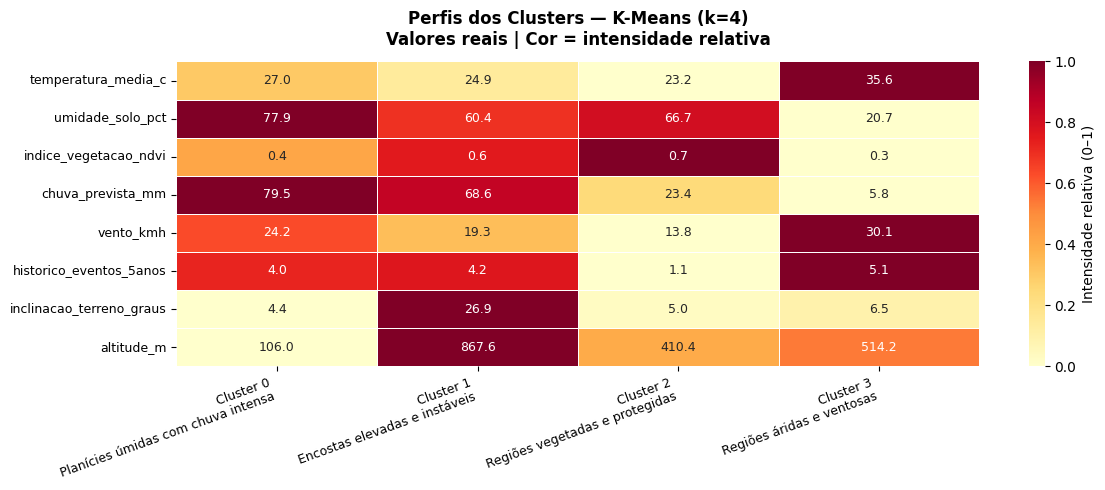

In [22]:
#  Heatmap normalizado dos perfis
# Normaliza cada feature para 0-1 para permitir comparação visual
from sklearn.preprocessing import MinMaxScaler

tabela_plot = tabela_clusters[features_km].copy()
scaler_plot  = MinMaxScaler()
tabela_norm  = pd.DataFrame(
    scaler_plot.fit_transform(tabela_plot),
    index=tabela_plot.index,
    columns=tabela_plot.columns
)
tabela_norm.index = [f"Cluster {i}\n{nomes[i]}" for i in tabela_norm.index]

import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(
    tabela_norm.T,
    annot=tabela_plot.T.values,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Intensidade relativa (0–1)"},
    annot_kws={"size": 9}
)
plt.title("Perfis dos Clusters — K-Means (k=4)\nValores reais | Cor = intensidade relativa",
          fontsize=12, fontweight="bold", pad=12)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("heatmap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

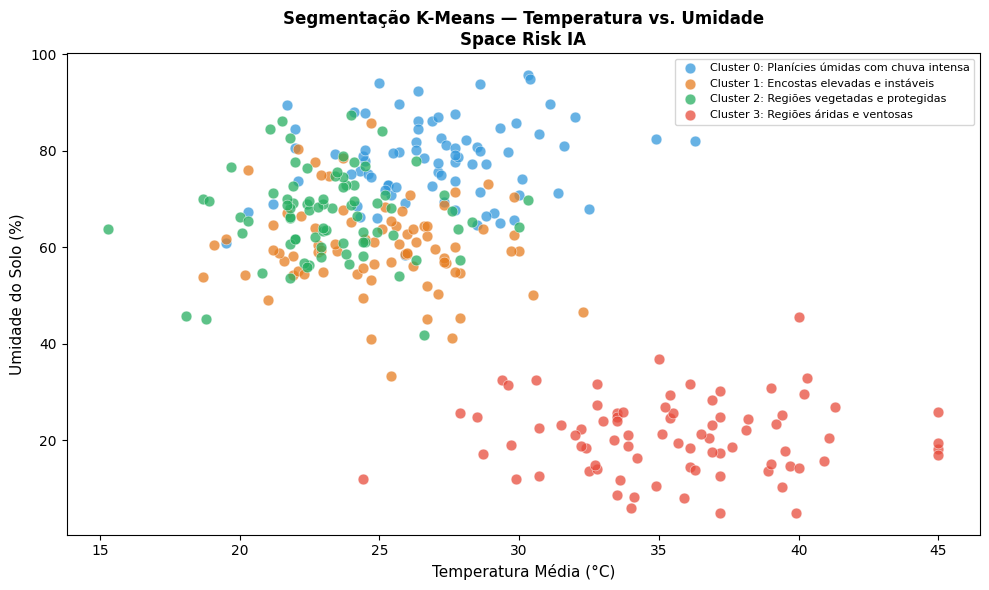

In [23]:
# Scatter: temperatura vs. umidade (2 features mais contrastantes)
cores = ["#3498db", "#e67e22", "#27ae60", "#e74c3c"]
labels_plot = [f"Cluster {i}: {nomes[i]}" for i in range(4)]

plt.figure(figsize=(10, 6))
for i in range(4):
    mask = df["cluster"] == i
    plt.scatter(
        df.loc[mask, "temperatura_media_c"],
        df.loc[mask, "umidade_solo_pct"],
        label=labels_plot[i],
        color=cores[i],
        alpha=0.75,
        edgecolors="white",
        linewidth=0.4,
        s=60
    )

plt.xlabel("Temperatura Média (°C)", fontsize=11)
plt.ylabel("Umidade do Solo (%)", fontsize=11)
plt.title("Segmentação K-Means — Temperatura vs. Umidade\nSpace Risk IA",
          fontsize=12, fontweight="bold")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("scatter_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise de Segmentação: Perfil de Riscos Regionais

A aplicação do algoritmo de clustering permitiu dividir as regiões em quatro perfis distintos, baseados exclusivamente em variáveis ambientais e operacionais. A validação via `indice_impacto` e `risco_alto` confirmou a eficácia da segmentação.

### 1. Resumo dos Clusters
Todos os 4 grupos mantiveram um equilíbrio estatístico, com 80 regiões cada (25% do total).

| Variável | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
| :--- | :---: | :---: | :---: | :---: |
| **Temp. Média (°C)** | 26,97 | 24,95 | 23,25 | 35,58 |
| **Umidade Solo (%)** | 77,87 | 60,38 | 66,72 | 20,67 |
| **NDVI (Veg.)** | 0,43 | 0,57 | 0,67 | 0,26 |
| **Chuva (mm)** | 79,53 | 68,64 | 23,40 | 5,75 |
| **Hist. Eventos** | 4,01 | 4,18 | 1,15 | 5,10 |
| **Risco Alto (%)** | **79%** | **88%** | **0%** | **84%** |

---

### 2. Caracterização dos Perfis

#### 🔵 Cluster 0: Planícies de Várzea
* **Perfil:** Áreas de baixa altitude (106 m) com alta umidade e precipitação.
* **Diagnóstico:** Regiões sujeitas a **inundações e alagamentos**. O risco é impulsionado pelo volume de chuva acumulada.

#### 🟠 Cluster 1: Encostas Instáveis
* **Perfil:** Alta altitude (867 m) e inclinação acentuada (26,9°).
* **Diagnóstico:** Regiões propensas a **deslizamentos e processos erosivos**. É o grupo de maior criticidade, com 88% de incidência de risco alto.

#### 🟢 Cluster 2: Zonas de Proteção Ambiental
* **Perfil:** Alta cobertura vegetal (NDVI 0,67) e condições climáticas amenas.
* **Diagnóstico:** As únicas regiões que funcionam como **escudo natural**. A densidade vegetal é o principal fator de mitigação, resultando em 0% de risco alto.

#### 🔴 Cluster 3: Zonas Áridas e Críticas
* **Perfil:** Temperaturas elevadas (35,6°C), solo seco (20,7%) e ventos fortes (30,1 km/h).
* **Diagnóstico:** Perfil de **alto risco para incêndios e estresse hídrico**. Apresenta o maior histórico de eventos críticos do dataset.

---
> **Nota Metodológica:** O `indice_impacto` e o `risco_alto` não foram utilizados no treinamento, funcionando estritamente como variáveis de validação externa para atestar a coerência dos agrupamentos.